In [1]:
import numpy as np
import h5py
from astropy.io import fits
from astropy.visualization import LogStretch, ImageNormalize
import os
from score_models import ScoreModel
from tqdm import tqdm
from glob import glob
import matplotlib.pyplot as plt

In [2]:
path = "/home/aadam/projects/rrg-lplevass/data/probes.h5"
hf = h5py.File(path, "r")

In [3]:
prior_path = "../models/ncsnpp_vp_probes_g_256_230824141338"
prior = ScoreModel(checkpoints_directory=prior_path)

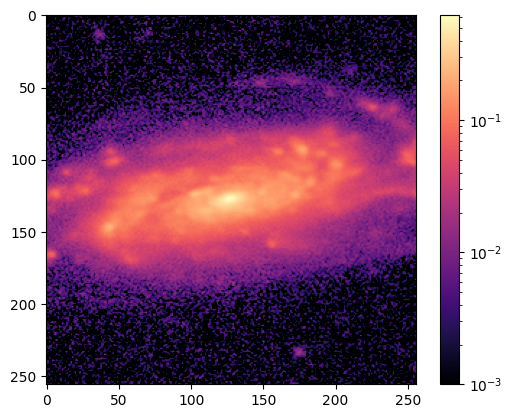

In [4]:
k = np.random.randint(len(hf["galaxies"]))
plt.imshow(hf["galaxies"][k, ..., 0], cmap="magma", norm=plt.cm.colors.LogNorm(vmin=1e-3, clip=True))
plt.colorbar()

In [13]:
# k = list(sorted(np.random.randint(len(hf["galaxies"]), size=100)))
# sample = hf["galaxies"][k]
# plt.hist(np.log10(sample.ravel() + 1e-3), bins=100);

In [14]:
B = 10
model_samples = prior.sample([B, 1, 256, 256], steps=1000)

Sampling from the prior | t = 0.0 | sigma = 4.5e-03| scale ~ 8.2e+00: 100%|██████████| 1000/1000 [07:35<00:00,  2.19it/s]


In [ ]:
fig, axs = plt.subplots(2, 5, figsize=(20, 8))

for i in range(2):
    for j in range(5):
        k = i * 5 + j
        axs[i, j].imshow(model_samples[k, 0].cpu(), cmap="magma", norm=plt.cm.colors.LogNorm(vmin=1e-2, clip=True))
        axs[i, j].axis("off")
plt.subplots_adjust(hspace=0, wspace=0)

In [ ]:
plt.hist(np.log10(model_samples.cpu().numpy().ravel() + 1e-3), bins=100);